<a href="https://colab.research.google.com/github/Eduar239/claude-skills/blob/main/Copy_of_Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Libraries loaded.
📂 Upload ATP (men's) xlsx file:


Saving ATP_Matches_Full.xlsx to ATP_Matches_Full.xlsx

📂 Upload WTA (women's) xlsx file:


Saving WTA_Matches_Full.xlsx to WTA_Matches_Full.xlsx

✅ ATP: 18,482 matches loaded
✅ WTA: 11,696 matches loaded
Sliding scale examples:
  ✅ Top 5 vs rank 40: score=1.00 | Rank 5 fav needs gap ≥ 10, gap is 35
  ✅ Rank 15 vs rank 50: score=0.20 | Rank 15 fav needs gap ≥ 25, gap is 35
  ❌ Rank 33 vs rank 37  ← should be NO: score=0.00 | Rank 33 fav needs gap ≥ 50, only 4 — skip
  ✅ Rank 80 vs rank 180: score=0.17 | Rank 80 fav needs gap ≥ 75, gap is 100
  ✅ Rank 380 vs rank 650: score=0.40 | Rank 380 fav needs gap ≥ 150, gap is 270
  ❌ Rank 350 vs rank 390 ← should be NO: score=0.00 | Rank 350 fav needs gap ≥ 150, only 40 — skip
  ❌ Rank 520 vs rank 700 ← should be NO: score=0.00 | Favourite ranked outside top 500 — skip

Cleaning data...
  ATP: removed 689 retirements → 17,793 remain
  WTA: removed 510 retirements → 11,186 remain
✅ Encodings done.
✅ Player sides randomised.

Applying betting universe filter...
  ATP: 9,586 bettable matches from 17,793 total (53.9%)
  Avg bettability sco

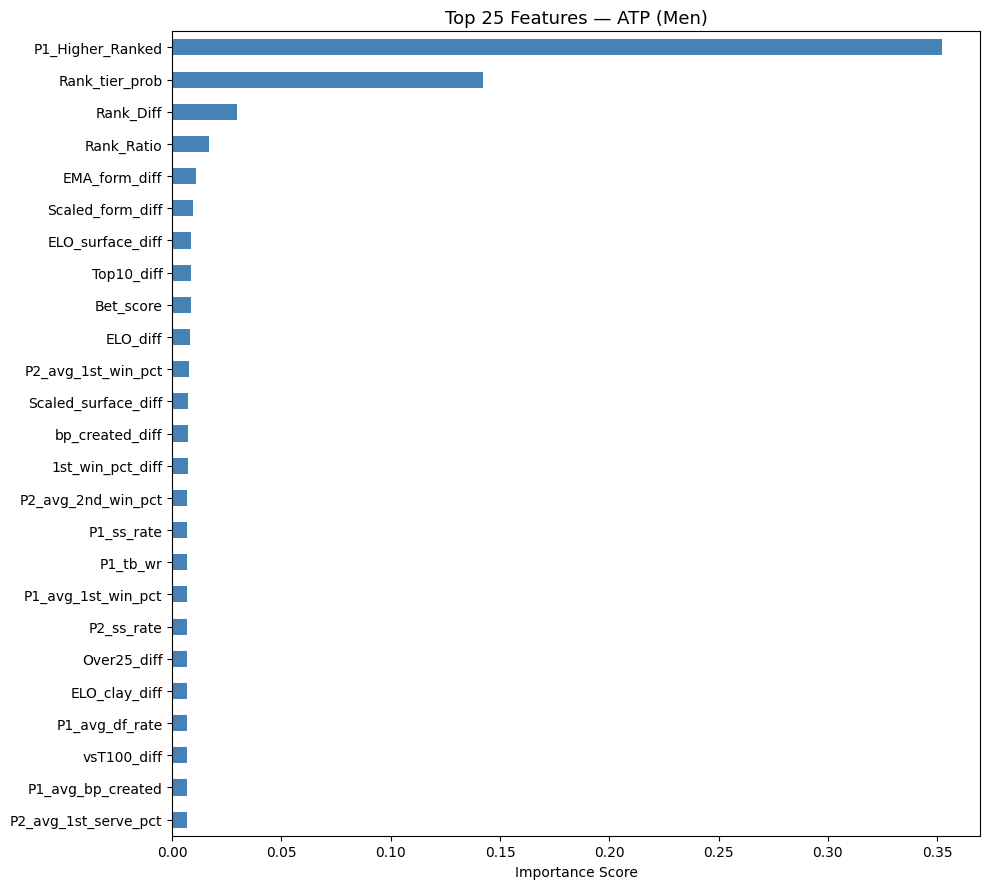

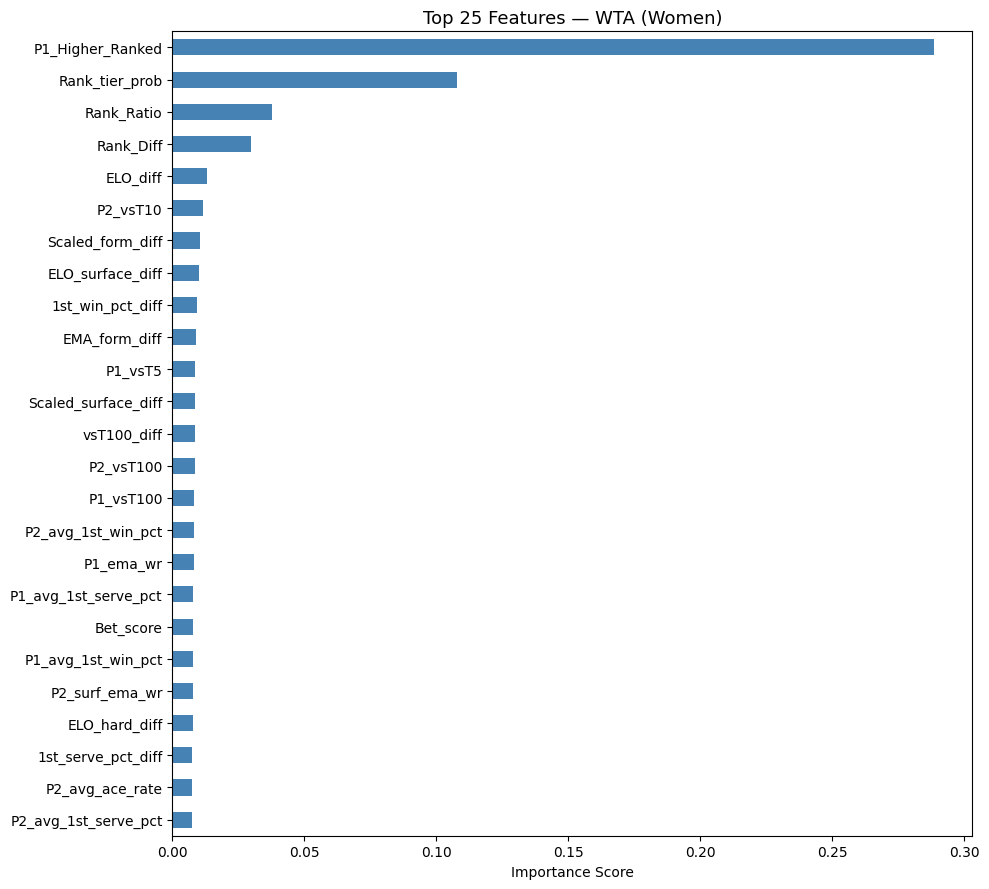


  ATP | Clay | SF | Masters 1000
  Alexander Zverev (#3) vs Casper Ruud (#15)
  Rank gap: 12 | Favourite: Alexander Zverev (#3)
────────────────────────────────────────────────────────────
  ✅ Inside betting universe (score: 0.10)
────────────────────────────────────────────────────────────
  Alexander Zverev           73.1%  █████████████████████
  Casper Ruud                26.9%  ████████
────────────────────────────────────────────────────────────
  🏆 Winner          : Alexander Zverev
  Confidence         : HIGH (73.1%)
  Bet depth          : Boundary — proceed with caution (score 0.10)
  H2H: neutral (< 3 meetings or no clear edge)
  Rank-tier base     : 76.0% P1 advantage
  ELO on Clay       : +44
  Form (EMA)         : 81% vs 65%
  Clay form          : 84% vs 74%
  Tiebreak rate      : 59% vs 60%
  Straight sets rate : 60% vs 67%

  ATP | Hard | F | ATP Tour
  Taylor Fritz (#7) vs Hubert Hurkacz (#63)
  Rank gap: 56 | Favourite: Taylor Fritz (#7)
──────────────────────────────

In [ ]:
# ================================================================
# TENNIS MATCH WINNER PREDICTION v6
# Core change: Sliding scale betting universe
#   The model now trains ONLY on matches you'd actually bet on.
#   Minimum rank gap scales up as players get lower-ranked.
#
#   Top 10 fav    → gap ≥  10  (78%+ always)
#   Rank 11–20    → gap ≥  25
#   Rank 21–50    → gap ≥  50
#   Rank 51–100   → gap ≥  75
#   Rank 101–200  → gap ≥  75
#   Rank 201–300  → gap ≥ 100
#   Rank 301–500  → gap ≥ 150
#   Rank 500+     → never bet / excluded
#
# All v5 features retained:
#   Rank-tier prob table, vs-rank-tier win rates, tiebreak rate,
#   straight sets rate, over/under tendency, EMA decay, H2H dominance,
#   top-10/20 consistency, surface ELO differentials, sample weights
# ================================================================


# ── CELL 1: Install & Import ─────────────────────────────────
!pip install xgboost --quiet

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded.")


# ── CELL 2: Load Both Files ──────────────────────────────────
from google.colab import files

print("📂 Upload ATP (men's) xlsx file:")
uploaded = files.upload()
atp_file = list(uploaded.keys())[0]

print("\n📂 Upload WTA (women's) xlsx file:")
uploaded = files.upload()
wta_file = list(uploaded.keys())[0]

atp_raw = pd.read_excel(atp_file)
wta_raw = pd.read_excel(wta_file)
atp_raw['Tour'] = 'ATP'
wta_raw['Tour'] = 'WTA'

print(f"\n✅ ATP: {len(atp_raw):,} matches loaded")
print(f"✅ WTA: {len(wta_raw):,} matches loaded")


# ── CELL 3: Sliding Scale Betting Universe ───────────────────
# This is the core logic of v6.
# Built directly from your data analysis.
# The model trains ONLY on matches inside your betting universe.

SLIDING_SCALE = [
    # (max_fav_rank, min_gap_required)
    (  10,  10),   # Top 10 fav  → gap ≥ 10
    (  20,  25),   # Rank 11-20  → gap ≥ 25
    (  50,  50),   # Rank 21-50  → gap ≥ 50
    ( 100,  75),   # Rank 51-100 → gap ≥ 75
    ( 200,  75),   # Rank 101-200→ gap ≥ 75
    ( 300, 100),   # Rank 201-300→ gap ≥ 100
    ( 500, 150),   # Rank 301-500→ gap ≥ 150
    # 500+: never — excluded entirely
]

def is_bettable(fav_rank, dog_rank):
    """
    Returns (bettable: bool, min_gap_required: int, reason: str)
    fav_rank = lower ranked number (better player)
    dog_rank = higher ranked number (worse player)
    """
    if pd.isna(fav_rank) or pd.isna(dog_rank):
        return False, 0, "Missing rank data"

    gap = dog_rank - fav_rank
    if gap <= 0:
        return False, 0, "Dog rank must be higher than fav rank"

    if fav_rank > 500:
        return False, 0, "Favourite ranked outside top 500 — skip"

    for max_rank, min_gap in SLIDING_SCALE:
        if fav_rank <= max_rank:
            if gap >= min_gap:
                return True, min_gap, f"Rank {fav_rank} fav needs gap ≥ {min_gap}, gap is {gap}"
            else:
                return False, min_gap, f"Rank {fav_rank} fav needs gap ≥ {min_gap}, only {gap} — skip"

    return False, 0, "Outside defined tiers"

def bettability_score(fav_rank, dog_rank):
    """
    Continuous score 0–1 measuring how deep inside the betting
    universe this match sits. Used as a feature in the model.
    0   = right at the boundary (barely qualifies)
    1   = far inside (large gap relative to minimum required)
    """
    bettable, min_gap, _ = is_bettable(fav_rank, dog_rank)
    if not bettable or min_gap == 0:
        return 0.0
    gap = dog_rank - fav_rank
    # How many times over the minimum threshold is the actual gap
    score = min((gap / min_gap) - 1.0, 2.0) / 2.0  # caps at 1.0
    return round(float(score), 4)

# Quick test
print("Sliding scale examples:")
test_cases = [
    (5,  40,  "Top 5 vs rank 40"),
    (15, 50,  "Rank 15 vs rank 50"),
    (33, 37,  "Rank 33 vs rank 37  ← should be NO"),
    (80, 180, "Rank 80 vs rank 180"),
    (380, 650,"Rank 380 vs rank 650"),
    (350, 390,"Rank 350 vs rank 390 ← should be NO"),
    (520, 700,"Rank 520 vs rank 700 ← should be NO"),
]
for fav, dog, desc in test_cases:
    ok, mg, reason = is_bettable(fav, dog)
    score = bettability_score(fav, dog)
    print(f"  {'✅' if ok else '❌'} {desc}: score={score:.2f} | {reason}")


# ── CELL 4: Clean & Derive Stats ─────────────────────────────
def clean(df, tour):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df['Surface'] = df['Surface'].fillna('Hard')

    n_before = len(df)
    df = df[~(df['Minutes'] <= 20)]
    df = df[~((df['Total Sets'] == 1) & (df['Minutes'] < 30))]
    df = df[df['Minutes'].notna()]
    df = df.reset_index(drop=True)
    print(f"  {tour}: removed {n_before-len(df):,} retirements → {len(df):,} remain")

    def pct(a, b):
        return np.where(b > 0, a / b, np.nan)

    df['W_1st_serve_pct']   = pct(df['W 1st In'],   df['W Srv Pts'])
    df['W_1st_win_pct']     = pct(df['W 1st Won'],  df['W 1st In'])
    df['W_2nd_win_pct']     = pct(df['W 2nd Won'],  df['W Srv Pts'] - df['W 1st In'])
    df['W_bp_save_pct']     = pct(df['W BP Saved'], df['W BP Faced'])
    df['W_ace_rate']        = pct(df['W Aces'],      df['W Srv Pts'])
    df['W_df_rate']         = pct(df['W DFs'],       df['W Srv Pts'])
    df['W_bp_created_rate'] = pct(df['L BP Faced'], df['L Srv Gms'])

    df['L_1st_serve_pct']   = pct(df['L 1st In'],   df['L Srv Pts'])
    df['L_1st_win_pct']     = pct(df['L 1st Won'],  df['L 1st In'])
    df['L_2nd_win_pct']     = pct(df['L 2nd Won'],  df['L Srv Pts'] - df['L 1st In'])
    df['L_bp_save_pct']     = pct(df['L BP Saved'], df['L BP Faced'])
    df['L_ace_rate']        = pct(df['L Aces'],      df['L Srv Pts'])
    df['L_df_rate']         = pct(df['L DFs'],       df['L Srv Pts'])

    df['went_distance'] = (
        ((df['Best Of']==3) & (df['Total Sets']==3)) |
        ((df['Best Of']==5) & (df['Total Sets']==5))
    ).astype(int)
    df['straight_sets']  = (df['Total Sets'] == 2).astype(int)
    df['over_2_5_sets']  = (df['Total Sets'] >= 3).astype(int)

    return df

print("\nCleaning data...")
atp = clean(atp_raw, 'ATP')
wta = clean(wta_raw, 'WTA')


# ── CELL 5: Encodings ────────────────────────────────────────
SURFACE_MAP = {'Hard':0,'Clay':1,'Grass':2,'Carpet':3,'Indoor':0}
ROUND_MAP   = {'RR':0,'R128':1,'R64':2,'R32':3,'R16':4,'QF':5,'SF':6,'F':7,'BR':4}
SERIES_MAP_ATP = {
    'ATP250':1,'ATP500':2,'Masters 1000':3,'Grand Slam':4,
    'ATP Tour':2,'Olympics':3,'NextGen':1,'Davis Cup':2,'United Cup':2
}
SERIES_MAP_WTA = {
    'International':1,'Premier':2,'Premier 5':3,'Premier Mandatory':3,
    'Grand Slam':4,'WTA 125':1,'WTA 250':1,'WTA 500':2,'WTA 1000':3,
    'Olympics':3,'United Cup':2,'Billie Jean King Cup':2
}

def encode(df, series_map):
    df = df.copy()
    df['Surface_enc'] = df['Surface'].map(SURFACE_MAP).fillna(0).astype(int)
    df['Round_enc']   = df['Round'].map(ROUND_MAP).fillna(3).astype(int)
    df['Series_enc']  = df['Series'].map(series_map).fillna(1).astype(int)
    return df

atp = encode(atp, SERIES_MAP_ATP)
wta = encode(wta, SERIES_MAP_WTA)
print("✅ Encodings done.")


# ── CELL 6: Randomise Player1 / Player2 ─────────────────────
def randomise_sides(df):
    df = df.copy()
    np.random.seed(42)
    flip = np.random.rand(len(df)) > 0.5
    df['P1']      = np.where(flip, df['Winner'],      df['Loser'])
    df['P2']      = np.where(flip, df['Loser'],       df['Winner'])
    df['P1_Rank'] = np.where(flip, df['Winner Rank'], df['Loser Rank'])
    df['P2_Rank'] = np.where(flip, df['Loser Rank'],  df['Winner Rank'])
    df['P1_Won']  = np.where(flip, 1, 0)

    stat_pairs = [
        ('1st_serve_pct','W_1st_serve_pct','L_1st_serve_pct'),
        ('1st_win_pct',  'W_1st_win_pct',  'L_1st_win_pct'),
        ('2nd_win_pct',  'W_2nd_win_pct',  'L_2nd_win_pct'),
        ('bp_save_pct',  'W_bp_save_pct',  'L_bp_save_pct'),
        ('ace_rate',     'W_ace_rate',     'L_ace_rate'),
        ('df_rate',      'W_df_rate',      'L_df_rate'),
        ('bp_created',   'W_bp_created_rate','W_bp_created_rate'),
    ]
    for name, wcol, lcol in stat_pairs:
        df[f'P1_{name}'] = np.where(flip, df[wcol], df[lcol])
        df[f'P2_{name}'] = np.where(flip, df[lcol], df[wcol])
    return df

atp = randomise_sides(atp)
wta = randomise_sides(wta)
print("✅ Player sides randomised.")


# ── CELL 7: Apply Betting Universe Filter ────────────────────
# This is where v6 fundamentally differs from all previous versions.
# We filter BEFORE computing rolling features so the model only
# learns patterns from matches inside your betting universe.

def apply_betting_universe(df, tour):
    """
    Applies the sliding scale filter.
    Also computes bettability_score as a feature.
    """
    df = df.copy()
    bettable_flags = []
    bet_scores     = []
    sample_weights = []

    for _, row in df.iterrows():
        r1, r2 = row['P1_Rank'], row['P2_Rank']

        # Identify favourite and underdog
        if pd.isna(r1) or pd.isna(r2):
            bettable_flags.append(False)
            bet_scores.append(0.0)
            sample_weights.append(1.0)
            continue

        fav_rank = min(r1, r2)
        dog_rank = max(r1, r2)

        ok, _, _ = is_bettable(fav_rank, dog_rank)
        score    = bettability_score(fav_rank, dog_rank)

        bettable_flags.append(ok)
        bet_scores.append(score)

        # Sample weight: deeper inside universe = higher weight
        # Boundary matches (score ~0) get 0.5 weight
        # Deep matches (score ~1) get full weight
        w = 0.5 + 0.5 * score if ok else 1.0
        sample_weights.append(w)

    df['_bettable']  = bettable_flags
    df['Bet_score']  = bet_scores
    df['_weight']    = sample_weights

    filtered = df[df['_bettable']].copy()
    total    = len(df)
    kept     = len(filtered)
    print(f"  {tour}: {kept:,} bettable matches from {total:,} total ({kept/total:.1%})")
    print(f"  Avg bettability score: {filtered['Bet_score'].mean():.2f}")
    return filtered

print("\nApplying betting universe filter...")
atp_bet = apply_betting_universe(atp, 'ATP')
wta_bet = apply_betting_universe(wta, 'WTA')


# ── CELL 8: Surface-Specific ELO ────────────────────────────
# Computed on FULL dataset so ratings are based on all history,
# then we only USE them on bettable matches for training.

def compute_elo(df, K_overall=32, K_surface=24, base=1500):
    df = df.copy().sort_values('Date').reset_index(drop=True)
    elo = {}
    elo_surf = {'Hard':{}, 'Clay':{}, 'Grass':{}}

    def get(d, p): return d.get(p, base)
    def exp_score(ra, rb): return 1.0/(1.0+10**((rb-ra)/400.0))

    w_elo,l_elo,w_h,l_h,w_c,l_c,w_g,l_g = [],[],[],[],[],[],[],[]

    for _, row in df.iterrows():
        w, l = row['Winner'], row['Loser']
        s    = row['Surface']

        rw=get(elo,w); rl=get(elo,l)
        rw_h=get(elo_surf['Hard'],w);  rl_h=get(elo_surf['Hard'],l)
        rw_c=get(elo_surf['Clay'],w);  rl_c=get(elo_surf['Clay'],l)
        rw_g=get(elo_surf['Grass'],w); rl_g=get(elo_surf['Grass'],l)

        w_elo.append(rw); l_elo.append(rl)
        w_h.append(rw_h); l_h.append(rl_h)
        w_c.append(rw_c); l_c.append(rl_c)
        w_g.append(rw_g); l_g.append(rl_g)

        ew = exp_score(rw, rl)
        elo[w] = rw + K_overall*(1-ew)
        elo[l] = rl + K_overall*(0-(1-ew))

        sk = s if s in elo_surf else 'Hard'
        sd = elo_surf[sk]
        rs_w=get(sd,w); rs_l=get(sd,l)
        esw = exp_score(rs_w, rs_l)
        sd[w] = rs_w + K_surface*(1-esw)
        sd[l] = rs_l + K_surface*(0-(1-esw))

    df['W_elo']=w_elo; df['L_elo']=l_elo
    df['W_elo_hard']=w_h; df['L_elo_hard']=l_h
    df['W_elo_clay']=w_c; df['L_elo_clay']=l_c
    df['W_elo_grass']=w_g;df['L_elo_grass']=l_g
    return df

print("\n⏳ Computing ELO for ATP (full dataset)...")
atp = compute_elo(atp)
print("⏳ Computing ELO for WTA (full dataset)...")
wta = compute_elo(wta)

def assign_elo_sides(df):
    df = df.copy()
    flip = (df['P1'] == df['Winner'])
    for col in ['elo','elo_hard','elo_clay','elo_grass']:
        df[f'P1_{col}'] = np.where(flip, df[f'W_{col}'], df[f'L_{col}'])
        df[f'P2_{col}'] = np.where(flip, df[f'L_{col}'], df[f'W_{col}'])
    return df

atp = assign_elo_sides(atp)
wta = assign_elo_sides(wta)

# Re-apply betting filter after ELO computed
atp_bet = apply_betting_universe(atp, 'ATP')
wta_bet = apply_betting_universe(wta, 'WTA')
print("✅ ELO done.")


# ── CELL 9: Rolling Features ─────────────────────────────────
STAT_COLS = [
    '1st_serve_pct','1st_win_pct','2nd_win_pct',
    'bp_save_pct','ace_rate','df_rate','bp_created'
]
RANK_TIERS = [
    ('vsT5',    1,   5),
    ('vsT10',   6,  10),
    ('vsT20',  11,  20),
    ('vsT50',  21,  50),
    ('vsT100', 51, 100),
    ('vsT200',101, 200),
]

RANK_PROB_TABLE = {
    'T1-3|O1-10':0.71,  'T1-3|O11-30':0.76,  'T1-3|O31-50':0.87,
    'T1-3|O51-80':0.90, 'T1-3|O81-150':0.93, 'T1-3|O151-300':0.87,'T1-3|O300+':0.92,
    'T4-10|O1-10':0.55, 'T4-10|O11-30':0.63, 'T4-10|O31-50':0.77,
    'T4-10|O51-80':0.78,'T4-10|O81-150':0.81,'T4-10|O151-300':0.76,'T4-10|O300+':0.85,
    'T11-20|O11-30':0.56,'T11-20|O31-50':0.60,'T11-20|O51-80':0.73,
    'T11-20|O81-150':0.71,'T11-20|O151-300':0.73,'T11-20|O300+':0.78,
    'T21-30|O31-50':0.50,'T21-30|O51-80':0.65,
    'T21-30|O81-150':0.69,'T21-30|O151-300':0.71,'T21-30|O300+':0.80,
    'T31-50|O51-80':0.55,'T31-50|O81-150':0.62,
    'T31-50|O151-300':0.68,'T31-50|O300+':0.71,
    'T51-80|O51-80':0.50,'T51-80|O81-150':0.54,
    'T51-80|O151-300':0.62,'T51-80|O300+':0.72
}

def rank_tier_prob(r1, r2):
    if pd.isna(r1) or pd.isna(r2): return 0.5
    if r1>=900 and r2>=900: return 0.5
    if r1>=900: return 0.20
    if r2>=900: return 0.85
    best=min(r1,r2); opp=max(r1,r2); fav_is_p1=(r1<r2)
    fb=('T1-3' if best<=3 else 'T4-10' if best<=10 else 'T11-20' if best<=20
        else 'T21-30' if best<=30 else 'T31-50' if best<=50 else 'T51-80')
    ob=('O1-10' if opp<=10 else 'O11-30' if opp<=30 else 'O31-50' if opp<=50
        else 'O51-80' if opp<=80 else 'O81-150' if opp<=150
        else 'O151-300' if opp<=300 else 'O300+')
    key=f'{fb}|{ob}'
    rf=RANK_PROB_TABLE.get(key,None)
    if rf is None:
        diff=opp-best
        rf=(0.82 if diff>200 else 0.74 if diff>100 else 0.65 if diff>50
            else 0.58 if diff>20 else 0.53 if diff>5 else 0.50)
    return rf if fav_is_p1 else (1-rf)

def rank_gap_adj_scale(r1, r2):
    if pd.isna(r1) or pd.isna(r2): return 0.5
    gap = abs(r1-r2) if (r1<900 and r2<900) else 50
    return max(0.30, 1.0 - gap*0.008)

def ema_win_rate(player, data, decay=0.1, min_m=3):
    played = data[(data['P1']==player)|(data['P2']==player)]
    if len(played)<min_m: return 0.5
    wins = np.where(played['P1']==player,
                    (played['P1_Won']==1).astype(float),
                    (played['P1_Won']==0).astype(float))
    w = np.exp(decay*np.arange(len(wins)))
    return float(np.average(wins, weights=w))

def ema_stat(player, data, stat, decay=0.1, n=20, min_m=3):
    p1r=data[data['P1']==player][f'P1_{stat}'].dropna().tail(n).values
    p2r=data[data['P2']==player][f'P2_{stat}'].dropna().tail(n).values
    vals=np.concatenate([p1r,p2r])
    if len(vals)<min_m: return np.nan
    w=np.exp(decay*np.arange(len(vals)))
    return float(np.average(vals,weights=w))

def top_rank_consistency(player, data, threshold, min_m=5):
    played=data[(data['P1']==player)|(data['P2']==player)]
    if len(played)<min_m: return 0.0
    ranks=np.where(played['P1']==player,
                   played['P1_Rank'].values,played['P2_Rank'].values)
    in_thr=(ranks<=threshold).sum()
    mw=np.log1p(len(played))/np.log1p(50)
    return float(in_thr/len(played))*min(mw,1.0)

def h2h_dominance(p1, p2, data, min_meetings=3, dom_threshold=0.65):
    m=data[((data['P1']==p1)&(data['P2']==p2))|
           ((data['P1']==p2)&(data['P2']==p1))]
    n=len(m)
    if n<min_meetings: return 0.5
    p1w=(((m['P1']==p1)&(m['P1_Won']==1)).sum()+
         ((m['P2']==p1)&(m['P1_Won']==0)).sum())
    rate=p1w/n
    if rate>=dom_threshold or rate<=(1-dom_threshold):
        return 0.5+(rate-0.5)*min(n/10.0,1.0)
    return 0.5

def recent_surface_wr(player, data, surface, n=10, decay=0.1, min_m=3):
    played=data[((data['P1']==player)|(data['P2']==player))&
                (data['Surface']==surface)].tail(n)
    if len(played)<min_m: return 0.5
    wins=np.where(played['P1']==player,
                  (played['P1_Won']==1).astype(float),
                  (played['P1_Won']==0).astype(float))
    w=np.exp(decay*np.arange(len(wins)))
    return float(np.average(wins,weights=w))

def vs_rank_tier_wr(player, data, r_min, r_max, min_m=3):
    opp_rank=np.where(data['P1']==player,data['P2_Rank'],data['P1_Rank'])
    played=data[((data['P1']==player)|(data['P2']==player))&
                (opp_rank>=r_min)&(opp_rank<=r_max)]
    if len(played)<min_m: return 0.5
    wins=(((played['P1']==player)&(played['P1_Won']==1)).sum()+
          ((played['P2']==player)&(played['P1_Won']==0)).sum())
    return wins/len(played)

def tiebreak_win_rate(player, data, min_m=3):
    played=data[((data['P1']==player)|(data['P2']==player))&
                (data['went_distance']==1)]
    if len(played)<min_m: return 0.5
    wins=(((played['P1']==player)&(played['P1_Won']==1)).sum()+
          ((played['P2']==player)&(played['P1_Won']==0)).sum())
    return wins/len(played)

def straight_sets_win_rate(player, data, min_m=3):
    won=data[((data['P1']==player)&(data['P1_Won']==1))|
             ((data['P2']==player)&(data['P1_Won']==0))]
    if len(won)<min_m: return 0.5
    return won['straight_sets'].mean()

def over_25_rate(player, data, min_m=5):
    played=data[((data['P1']==player)|(data['P2']==player))&
                (data['Total Sets'].notna())]
    if len(played)<min_m: return 0.5
    return played['over_2_5_sets'].mean()

def rolling_features(df):
    # NOTE: we compute rolling features using the FULL dataset as past,
    # so player histories include all matches, not just bettable ones.
    # This gives richer rolling stats even for players who appear in
    # non-bettable matches.
    print(f"  Computing rolling features for {len(df):,} matches...")
    records = []

    for idx, row in df.iterrows():
        date    = row['Date']
        p1, p2  = row['P1'], row['P2']
        surface = row['Surface']
        r1, r2  = row['P1_Rank'], row['P2_Rank']
        past    = df[df['Date'] < date]
        rec     = {'idx': idx}

        rec['P1_ema_wr']      = ema_win_rate(p1, past)
        rec['P2_ema_wr']      = ema_win_rate(p2, past)
        rec['P1_surf_ema_wr'] = recent_surface_wr(p1, past, surface)
        rec['P2_surf_ema_wr'] = recent_surface_wr(p2, past, surface)
        rec['Rank_tier_prob'] = rank_tier_prob(r1, r2)
        adj = rank_gap_adj_scale(r1, r2)
        rec['Adj_scale']      = adj
        rec['Scaled_form_diff']    = (rec['P1_ema_wr']-rec['P2_ema_wr'])*adj
        rec['Scaled_surface_diff'] = (rec['P1_surf_ema_wr']-rec['P2_surf_ema_wr'])*adj
        rec['P1_top10_score'] = top_rank_consistency(p1, past, 10)
        rec['P2_top10_score'] = top_rank_consistency(p2, past, 10)
        rec['P1_top20_score'] = top_rank_consistency(p1, past, 20)
        rec['P2_top20_score'] = top_rank_consistency(p2, past, 20)
        rec['H2H_dominance']  = h2h_dominance(p1, p2, past)

        for name, rmin, rmax in RANK_TIERS:
            rec[f'P1_{name}'] = vs_rank_tier_wr(p1, past, rmin, rmax)
            rec[f'P2_{name}'] = vs_rank_tier_wr(p2, past, rmin, rmax)

        rec['P1_tb_wr']   = tiebreak_win_rate(p1, past)
        rec['P2_tb_wr']   = tiebreak_win_rate(p2, past)
        rec['P1_ss_rate'] = straight_sets_win_rate(p1, past)
        rec['P2_ss_rate'] = straight_sets_win_rate(p2, past)
        rec['P1_over25']  = over_25_rate(p1, past)
        rec['P2_over25']  = over_25_rate(p2, past)

        for stat in STAT_COLS:
            rec[f'P1_avg_{stat}'] = ema_stat(p1, past, stat)
            rec[f'P2_avg_{stat}'] = ema_stat(p2, past, stat)

        records.append(rec)
        if idx % 2000 == 0 and idx > 0:
            print(f"    → {idx:,} / {len(df):,}...")

    return pd.DataFrame(records).set_index('idx')

print("\n⏳ ATP rolling features (~6 min)...")
atp = atp.join(rolling_features(atp))
print("✅ ATP done.")

print("\n⏳ WTA rolling features (~5 min)...")
wta = wta.join(rolling_features(wta))
print("✅ WTA done.")

# Re-apply betting filter after rolling features computed
atp_bet = apply_betting_universe(atp, 'ATP')
wta_bet = apply_betting_universe(wta, 'WTA')


# ── CELL 10: Final Feature Engineering ──────────────────────
def build_features(df):
    df = df.copy()
    df['Rank_Diff']        = df['P1_Rank'] - df['P2_Rank']
    df['Rank_Ratio']       = df['P1_Rank'] / (df['P2_Rank']+1)
    df['P1_Higher_Ranked'] = (df['P1_Rank'] < df['P2_Rank']).astype(int)
    df['ELO_diff']         = df['P1_elo']       - df['P2_elo']
    df['ELO_hard_diff']    = df['P1_elo_hard']  - df['P2_elo_hard']
    df['ELO_clay_diff']    = df['P1_elo_clay']  - df['P2_elo_clay']
    df['ELO_grass_diff']   = df['P1_elo_grass'] - df['P2_elo_grass']

    def surf_elo(row):
        s = row['Surface']
        if s=='Clay':  return row['ELO_clay_diff']
        if s=='Grass': return row['ELO_grass_diff']
        return row['ELO_hard_diff']
    df['ELO_surface_diff'] = df.apply(surf_elo, axis=1)

    df['EMA_form_diff']    = df['P1_ema_wr']      - df['P2_ema_wr']
    df['EMA_surface_diff'] = df['P1_surf_ema_wr'] - df['P2_surf_ema_wr']
    df['Top10_diff']       = df['P1_top10_score'] - df['P2_top10_score']
    df['Top20_diff']       = df['P1_top20_score'] - df['P2_top20_score']

    for name,_,__ in RANK_TIERS:
        df[f'{name}_diff'] = df[f'P1_{name}'] - df[f'P2_{name}']

    df['TB_diff']     = df['P1_tb_wr']   - df['P2_tb_wr']
    df['SS_diff']     = df['P1_ss_rate'] - df['P2_ss_rate']
    df['Over25_diff'] = df['P1_over25']  - df['P2_over25']

    for stat in STAT_COLS:
        df[f'{stat}_diff'] = df[f'P1_avg_{stat}'] - df[f'P2_avg_{stat}']

    return df

atp_bet = build_features(atp_bet)
wta_bet = build_features(wta_bet)
atp     = build_features(atp)
wta     = build_features(wta)

FEATURES = [
    # Rank
    'Rank_Diff','Rank_Ratio','P1_Higher_Ranked',
    # Betting universe depth
    'Bet_score',
    # Rank-tier calibrated probability
    'Rank_tier_prob',
    # ELO differentials
    'ELO_diff','ELO_surface_diff',
    'ELO_hard_diff','ELO_clay_diff','ELO_grass_diff',
    # Context
    'Surface_enc','Round_enc','Series_enc',
    # EMA win rates
    'P1_ema_wr','P2_ema_wr',
    'P1_surf_ema_wr','P2_surf_ema_wr',
    'EMA_form_diff','EMA_surface_diff',
    'Scaled_form_diff','Scaled_surface_diff','Adj_scale',
    # Top-rank consistency
    'P1_top10_score','P2_top10_score',
    'P1_top20_score','P2_top20_score',
    'Top10_diff','Top20_diff',
    # H2H dominance
    'H2H_dominance',
    # vs rank tiers
    'P1_vsT5','P2_vsT5','vsT5_diff',
    'P1_vsT10','P2_vsT10','vsT10_diff',
    'P1_vsT20','P2_vsT20','vsT20_diff',
    'P1_vsT50','P2_vsT50','vsT50_diff',
    'P1_vsT100','P2_vsT100','vsT100_diff',
    'P1_vsT200','P2_vsT200','vsT200_diff',
    # Tiebreak / match style
    'P1_tb_wr','P2_tb_wr','TB_diff',
    'P1_ss_rate','P2_ss_rate','SS_diff',
    'P1_over25','P2_over25','Over25_diff',
    # Serve stats
    'P1_avg_1st_serve_pct','P2_avg_1st_serve_pct',
    'P1_avg_1st_win_pct',  'P2_avg_1st_win_pct',
    'P1_avg_2nd_win_pct',  'P2_avg_2nd_win_pct',
    'P1_avg_bp_save_pct',  'P2_avg_bp_save_pct',
    'P1_avg_ace_rate',     'P2_avg_ace_rate',
    'P1_avg_df_rate',      'P2_avg_df_rate',
    'P1_avg_bp_created',   'P2_avg_bp_created',
    '1st_serve_pct_diff','1st_win_pct_diff',
    '2nd_win_pct_diff','bp_save_pct_diff',
    'ace_rate_diff','df_rate_diff','bp_created_diff',
]

TARGET = 'P1_Won'
print(f"\n✅ Feature set: {len(FEATURES)} features")


# ── CELL 11: Train Models ────────────────────────────────────
def cross_val_weighted(model, X, y, weights, cv):
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        X_tr,X_val = X.iloc[train_idx],X.iloc[val_idx]
        y_tr,y_val = y.iloc[train_idx],y.iloc[val_idx]
        w_tr       = weights.iloc[train_idx]
        m = XGBClassifier(
            n_estimators=600, max_depth=4, learning_rate=0.03,
            subsample=0.8, colsample_bytree=0.7, min_child_weight=8,
            gamma=1.5, reg_alpha=0.2, reg_lambda=2.0,
            use_label_encoder=False, eval_metric='logloss', random_state=42
        )
        m.fit(X_tr, y_tr, sample_weight=w_tr)
        scores.append(accuracy_score(y_val, m.predict(X_val)))
    return np.array(scores)

def train_model(df, label):
    model_df = df[FEATURES+[TARGET,'_weight']].dropna(subset=FEATURES+[TARGET])
    X = model_df[FEATURES]
    y = model_df[TARGET]
    w = model_df['_weight']

    print(f"\n{'='*56}")
    print(f"  {label} Model")
    print(f"  Bettable training samples : {len(X):,}")
    print(f"  Class balance             : {y.mean():.2%} P1 wins")
    print(f"  Avg sample weight         : {w.mean():.2f}")
    print(f"{'='*56}")

    xgb = XGBClassifier(
        n_estimators=600, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=8,
        gamma=1.5, reg_alpha=0.2, reg_lambda=2.0,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    )
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_weighted(xgb, X, y, w, cv)

    print(f"  CV fold scores : {[f'{s:.3f}' for s in scores]}")
    print(f"  Mean accuracy  : {scores.mean():.3f} ± {scores.std():.3f}")

    calibrated = CalibratedClassifierCV(xgb, cv=5, method='isotonic')
    calibrated.fit(X, y, sample_weight=w)
    xgb.fit(X, y, sample_weight=w)
    return calibrated, xgb, X, y, scores

atp_model,atp_xgb,atp_X,atp_y,atp_scores = train_model(atp_bet, 'ATP (Men)')
wta_model,wta_xgb,wta_X,wta_y,wta_scores = train_model(wta_bet, 'WTA (Women)')
print("\n✅ Both models trained.")


# ── CELL 12: Feature Importance ─────────────────────────────
def plot_importance(xgb_model, title, top_n=25):
    imp = pd.Series(xgb_model.feature_importances_, index=FEATURES)
    imp = imp.nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(10, 9))
    imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top {top_n} Features — {title}', fontsize=13)
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

plot_importance(atp_xgb, 'ATP (Men)')
plot_importance(wta_xgb, 'WTA (Women)')


# ── CELL 13: ELO Helper ──────────────────────────────────────
def get_current_elo(player, df):
    m = df[(df['Winner']==player)|(df['Loser']==player)]
    if len(m)==0:
        return {'overall':1500,'hard':1500,'clay':1500,'grass':1500}
    last = m.iloc[-1]
    p = 'W' if last['Winner']==player else 'L'
    return {'overall':last[f'{p}_elo'],'hard':last[f'{p}_elo_hard'],
            'clay':last[f'{p}_elo_clay'],'grass':last[f'{p}_elo_grass']}


# ── CELL 14: Predict a Match ─────────────────────────────────
def predict_match(player1, player2, surface, round_name='QF',
                  tour='ATP', series='ATP500'):
    src   = atp   if tour=='ATP' else wta
    model = atp_model if tour=='ATP' else wta_model
    s_map = SERIES_MAP_ATP if tour=='ATP' else SERIES_MAP_WTA
    past  = src.copy()

    surf_enc   = SURFACE_MAP.get(surface, 0)
    round_enc  = ROUND_MAP.get(round_name, 4)
    series_enc = s_map.get(series, 2)

    def get_rank(player):
        m=past[(past['P1']==player)|(past['P2']==player)]
        if len(m)==0: return 999
        last=m.iloc[-1]
        return last['P1_Rank'] if last['P1']==player else last['P2_Rank']

    def avg_stat(player, stat):
        p1r=past[past['P1']==player][f'P1_avg_{stat}'].dropna().tail(20).values
        p2r=past[past['P2']==player][f'P2_avg_{stat}'].dropna().tail(20).values
        vals=np.concatenate([p1r,p2r])
        if len(vals)<3: return np.nan
        w=np.exp(0.1*np.arange(len(vals)))
        return float(np.average(vals,weights=w))

    r1, r2   = get_rank(player1), get_rank(player2)
    fav_rank = min(r1, r2)
    dog_rank = max(r1, r2)
    fav_name = player1 if r1 < r2 else player2

    # ── Betting universe check ─────────────────────────────────
    bettable, min_gap, reason = is_bettable(fav_rank, dog_rank)
    bet_score = bettability_score(fav_rank, dog_rank)

    print(f"\n{'='*60}")
    print(f"  {tour} | {surface} | {round_name} | {series}")
    print(f"{'='*60}")
    print(f"  {player1} (#{r1}) vs {player2} (#{r2})")
    print(f"  Rank gap: {abs(r1-r2)} | Favourite: {fav_name} (#{fav_rank})")
    print(f"{'─'*60}")

    if not bettable:
        print(f"  ⚠️  OUTSIDE BETTING UNIVERSE — {reason}")
        print(f"  Minimum gap required for rank #{fav_rank}: {min_gap}")
        print(f"  Prediction suppressed. This match does not meet your criteria.")
        print(f"{'='*60}")
        return None, None

    print(f"  ✅ Inside betting universe (score: {bet_score:.2f})")
    print(f"{'─'*60}")

    elo1 = get_current_elo(player1, src)
    elo2 = get_current_elo(player2, src)
    elo_diff       = elo1['overall']-elo2['overall']
    elo_hard_diff  = elo1['hard']-elo2['hard']
    elo_clay_diff  = elo1['clay']-elo2['clay']
    elo_grass_diff = elo1['grass']-elo2['grass']
    surf_elo_diff  = {'Hard':elo_hard_diff,'Clay':elo_clay_diff,
                      'Grass':elo_grass_diff}.get(surface,elo_hard_diff)

    p1_ema   = ema_win_rate(player1, past)
    p2_ema   = ema_win_rate(player2, past)
    p1_sema  = recent_surface_wr(player1, past, surface)
    p2_sema  = recent_surface_wr(player2, past, surface)
    p1_t10   = top_rank_consistency(player1, past, 10)
    p2_t10   = top_rank_consistency(player2, past, 10)
    p1_t20   = top_rank_consistency(player1, past, 20)
    p2_t20   = top_rank_consistency(player2, past, 20)
    h2h      = h2h_dominance(player1, player2, past)
    rtp      = rank_tier_prob(r1, r2)
    adj      = rank_gap_adj_scale(r1, r2)
    p1_tb    = tiebreak_win_rate(player1, past)
    p2_tb    = tiebreak_win_rate(player2, past)
    p1_ss    = straight_sets_win_rate(player1, past)
    p2_ss    = straight_sets_win_rate(player2, past)
    p1_o25   = over_25_rate(player1, past)
    p2_o25   = over_25_rate(player2, past)

    row = {
        'Rank_Diff':r1-r2,'Rank_Ratio':r1/(r2+1),
        'P1_Higher_Ranked':int(r1<r2),
        'Bet_score':bet_score,
        'Rank_tier_prob':rtp,
        'ELO_diff':elo_diff,'ELO_surface_diff':surf_elo_diff,
        'ELO_hard_diff':elo_hard_diff,'ELO_clay_diff':elo_clay_diff,
        'ELO_grass_diff':elo_grass_diff,
        'Surface_enc':surf_enc,'Round_enc':round_enc,'Series_enc':series_enc,
        'P1_ema_wr':p1_ema,'P2_ema_wr':p2_ema,
        'P1_surf_ema_wr':p1_sema,'P2_surf_ema_wr':p2_sema,
        'EMA_form_diff':p1_ema-p2_ema,'EMA_surface_diff':p1_sema-p2_sema,
        'Scaled_form_diff':(p1_ema-p2_ema)*adj,
        'Scaled_surface_diff':(p1_sema-p2_sema)*adj,
        'Adj_scale':adj,
        'P1_top10_score':p1_t10,'P2_top10_score':p2_t10,
        'P1_top20_score':p1_t20,'P2_top20_score':p2_t20,
        'Top10_diff':p1_t10-p2_t10,'Top20_diff':p1_t20-p2_t20,
        'H2H_dominance':h2h,
        'P1_tb_wr':p1_tb,'P2_tb_wr':p2_tb,'TB_diff':p1_tb-p2_tb,
        'P1_ss_rate':p1_ss,'P2_ss_rate':p2_ss,'SS_diff':p1_ss-p2_ss,
        'P1_over25':p1_o25,'P2_over25':p2_o25,'Over25_diff':p1_o25-p2_o25,
    }
    for name,rmin,rmax in RANK_TIERS:
        v1=vs_rank_tier_wr(player1,past,rmin,rmax)
        v2=vs_rank_tier_wr(player2,past,rmin,rmax)
        row[f'P1_{name}']=v1; row[f'P2_{name}']=v2
        row[f'{name}_diff']=v1-v2
    for stat in STAT_COLS:
        v1=avg_stat(player1,stat); v2=avg_stat(player2,stat)
        row[f'P1_avg_{stat}']=v1; row[f'P2_avg_{stat}']=v2
        row[f'{stat}_diff']=(v1 or 0)-(v2 or 0)

    X_pred = pd.DataFrame([row])[FEATURES].fillna(0)
    prob   = model.predict_proba(X_pred)[0]
    p1_p, p2_p = prob[1], prob[0]
    winner     = player1 if p1_p>p2_p else player2
    conf       = max(p1_p, p2_p)
    conf_label = 'HIGH' if conf>0.70 else 'MEDIUM' if conf>0.58 else 'LOW'
    bar1='█'*int(p1_p*30); bar2='█'*int(p2_p*30)

    h2h_note = (f"H2H edge: {player1 if h2h>0.5 else player2} (dominance active)"
                if h2h!=0.5 else "H2H: neutral (< 3 meetings or no clear edge)")
    depth    = ('Deep in universe' if bet_score>0.7
                else 'Mid universe' if bet_score>0.3
                else 'Boundary — proceed with caution')

    print(f"  {player1[:26]:<26} {p1_p:>5.1%}  {bar1}")
    print(f"  {player2[:26]:<26} {p2_p:>5.1%}  {bar2}")
    print(f"{'─'*60}")
    print(f"  🏆 Winner          : {winner}")
    print(f"  Confidence         : {conf_label} ({conf:.1%})")
    print(f"  Bet depth          : {depth} (score {bet_score:.2f})")
    print(f"  {h2h_note}")
    print(f"  Rank-tier base     : {rtp:.1%} P1 advantage")
    print(f"  ELO on {surface:<5}      : {surf_elo_diff:+.0f}")
    print(f"  Form (EMA)         : {p1_ema:.0%} vs {p2_ema:.0%}")
    print(f"  {surface} form          : {p1_sema:.0%} vs {p2_sema:.0%}")
    print(f"  Tiebreak rate      : {p1_tb:.0%} vs {p2_tb:.0%}")
    print(f"  Straight sets rate : {p1_ss:.0%} vs {p2_ss:.0%}")
    print(f"{'='*60}")
    return winner, p1_p


# ── CELL 15: Examples ────────────────────────────────────────
# ✅ Should predict
predict_match('Alexander Zverev', 'Casper Ruud',
              surface='Clay', round_name='SF', tour='ATP', series='Masters 1000')
predict_match('Taylor Fritz', 'Hubert Hurkacz',
              surface='Hard', round_name='F',  tour='ATP', series='ATP Tour')
predict_match('Elena Rybakina', 'Xinyu Gao',
              surface='Hard', round_name='QF', tour='WTA', series='International')

# ❌ Should be blocked (gap too small for rank tier)
predict_match('Stefanos Tsitsipas', 'Ugo Humbert',
              surface='Hard', round_name='QF', tour='ATP', series='ATP500')


# ── CELL 16: Model Summary ────────────────────────────────────
print("\n" + "="*60)
print("  MODEL PERFORMANCE SUMMARY — v6")
print("="*60)
print(f"  ATP (Men)   — CV Accuracy: {atp_scores.mean():.3f} ± {atp_scores.std():.3f}")
print(f"  WTA (Women) — CV Accuracy: {wta_scores.mean():.3f} ± {wta_scores.std():.3f}")
print(f"\n  ⚠️  IMPORTANT: These numbers are now measured ONLY")
print(f"  on matches inside your betting universe.")
print(f"  Comparison to previous versions is not direct —")
print(f"  v6 is solving a harder, more specific problem.")
print(f"\n  Sliding scale applied:")
for max_r, min_g in SLIDING_SCALE:
    print(f"    Rank ≤ {max_r:<4} → gap ≥ {min_g}")
print(f"    Rank > 500  → excluded")
print(f"\n  Version history (overall accuracy):")
print(f"  v2 → ATP 62.4% | WTA 61.4%  (all matches)")
print(f"  v5 → ATP 61.0% | WTA 62.0%  (all matches)")
print(f"  v6 → ATP {atp_scores.mean():.1%} | WTA {wta_scores.mean():.1%}  (betting universe only)")
print(f"\n  Benchmarks (betting universe):")
print(f"  • Rank-only baseline : ~63%")
print(f"  • Literature best    : ~72-74%")
print("="*60)